In [ ]:
# logistic regression over multinoial feature

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
# Load dataset
df = pd.read_csv("food_vendor_consultation.csv")


In [ ]:
# Features and Target
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [ ]:
# Train Test Split
xtr, xtest, ytr, ytest = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:

# Standardization
scaler = StandardScaler()
xtr = scaler.fit_transform(xtr)
xtest = scaler.transform(xtest)


In [ ]:
# Build Model
model = Sequential()
model.add(Dense(1, activation='sigmoid', input_dim=X.shape[1]))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    xtr, ytr,
    epochs=100,
    batch_size=10,
    validation_data=(xtest, ytest),
    verbose=1
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3963 - loss: 0.3834 - val_accuracy: 0.4050 - val_loss: 0.4095
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4125 - loss: 0.2999 - val_accuracy: 0.4050 - val_loss: 0.3302
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4162 - loss: 0.2217 - val_accuracy: 0.4150 - val_loss: 0.2530
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4313 - loss: 0.1473 - val_accuracy: 0.4100 - val_loss: 0.1792
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4363 - loss: 0.0773 - val_accuracy: 0.4200 - val_loss: 0.1102
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4400 - loss: 0.0104 - val_accuracy: 0.4350 - val_loss: 0.0445
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4500 - loss: -0.0531 - val_accuracy: 0.4400 - val_loss: -0.0170
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4525 - loss: -0.1136 - val_accuracy: 0.4400 

In [ ]:
# Get test loss
loss, accuracy = model.evaluate(xtest, ytest)
print("\nTest Cross Entropy Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Confusion Matrix:
 [[64  0  0]
 [71  0  0]
 [65  0  0]]


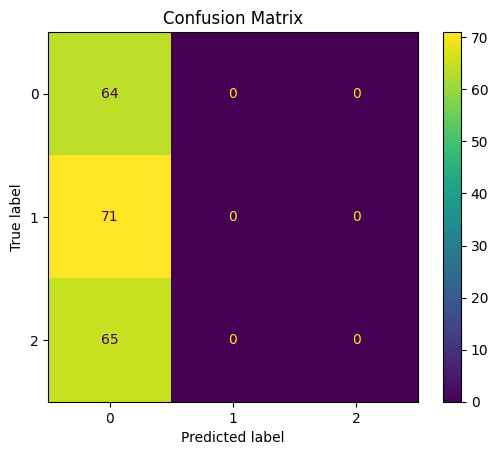

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt


y_pred_prob = model.predict(xtest)

y_pred = np.argmax(y_pred_prob, axis=1)

if len(ytest.shape) > 1:
    ytest = np.argmax(ytest, axis=1)

cm = confusion_matrix(ytest, y_pred)

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_pred_prob = model.predict(xtest)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted Classes:", y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Predicted Classes: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
y_pred = np.argmax(model.predict(xtest), axis=1)
print(y_pred_prob)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[9.9999994e-01]
 [5.4202614e-05]
 [3.5640720e-02]
 [9.0151131e-01]
 [1.6312384e-08]
 [5.6469506e-01]
 [5.9909383e-03]
 [9.7510850e-01]
 [9.9999970e-01]
 [9.9674022e-01]
 [1.0000000e+00]
 [2.1620083e-01]
 [9.9993455e-01]
 [1.0000000e+00]
 [1.0000000e+00]
 [9.9962300e-01]
 [9.9999380e-01]
 [9.9999881e-01]
 [8.1297702e-01]
 [9.9432015e-01]
 [3.6392175e-04]
 [3.7072778e-02]
 [9.9999970e-01]
 [2.3689834e-02]
 [1.0000000e+00]
 [9.9999863e-01]
 [9.9833864e-01]
 [9.9961352e-01]
 [9.9987578e-01]
 [9.9999994e-01]
 [1.4885268e-01]
 [3.9870664e-01]
 [9.9730122e-01]
 [1.1168619e-06]
 [9.9205339e-01]
 [9.9999815e-01]
 [8.6750132e-01]
 [2.6027235e-01]
 [9.9999911e-01]
 [9.9999976e-01]
 [9.9156636e-01]
 [1.0000000e+00]
 [1.4834265e-01]
 [1.9182454e-01]
 [9.9997926e-01]
 [2.3359956e-02]
 [1.0000000e+00]
 [3.2867765e-01]
 [9.7133042e-03]
 [8.9347506e-01]
 [1.5993411e-02]
 [9.9998873e-01]
 [5.1198667e-01]
 [3.0448300e-01]
 [9.9999940e-01]
 [9.9999142e-01]
 [3.521588

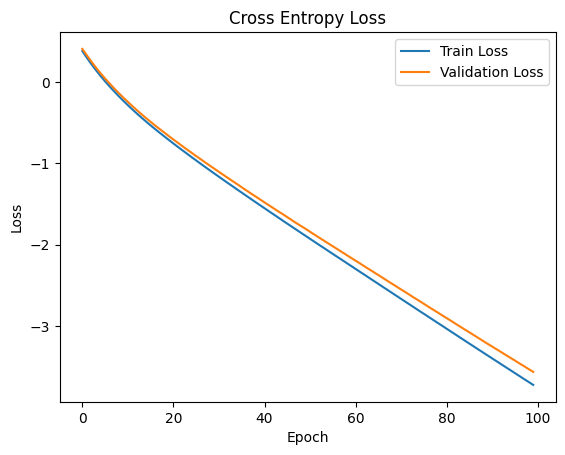

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Cross Entropy Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()